# Facial Emotion Recognition — Professional 85-90% Pipeline

## Why this will hit 85-90%

| What changed | Why it matters |
|---|---|
| EfficientNetB2 instead of B0 | Better feature extraction, higher capacity |
| 224×224 input | Full resolution — no spatial detail lost |
| No MixUp | Was hiding real train accuracy, causing confusion |
| Warmup + Cosine LR | Stable training from epoch 1 |
| 3-phase training | Gradual unfreeze = maximum accuracy |
| Test Time Augmentation | Free +1-2% accuracy at inference |
| Label smoothing 0.05 | Less aggressive, better for clean evaluation |

## Training Time Estimate (T4 GPU)
- Phase 1: ~25 min
- Phase 2: ~60 min  
- Phase 3: ~90 min
- **Total: ~3 hours**

In [1]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [2]:
import tensorflow as tf

tf.config.optimizer.set_experimental_options({
    "layout_optimizer": False
})

2026-03-22 12:11:07.710268: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774181467.945906      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774181468.013155      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774181468.556737      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774181468.556775      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774181468.556778      55 computation_placer.cc:177] computation placer alr

In [3]:
# ================================================================
# CELL 1 — IMPORTS
# ================================================================
import os, json, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.optimizers import AdamW
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

tf.random.set_seed(42)
np.random.seed(42)

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs : {len(gpus)}")
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")

GPUs : 2
TensorFlow : 2.19.0
Keras      : 3.10.0


In [4]:
# ================================================================
# CELL 2 — CONFIG
# All hyperparameters in one place.
# ================================================================

# Paths
DATASET_PATH   = "/kaggle/input/datasets/msambare/fer2013"
TRAIN_PATH     = os.path.join(DATASET_PATH, "train")
TEST_PATH      = os.path.join(DATASET_PATH, "test")
MODEL_PATH     = "best_emotion_model.keras"
CLASS_JSON     = "class_names.json"

# Image
IMG_SIZE       = 224          # EfficientNetB2 native resolution
BATCH_SIZE     = 32           # smaller batch for 224x224 to fit T4 VRAM
AUTOTUNE       = tf.data.AUTOTUNE

# Phase 1 — train head only (backbone frozen)
P1_EPOCHS      = 12
P1_LR          = 1e-3

# Phase 2 — unfreeze top 60 layers
P2_EPOCHS      = 20
P2_LR          = 1e-4
P2_UNFREEZE    = 120           # unfreeze last 60 layers of backbone

# Phase 3 — unfreeze all, very low LR
P3_EPOCHS      = 15
P3_LR          = 1e-5

# Regularisation
LABEL_SMOOTH   = 0.1         # light smoothing only
WARMUP_EPOCHS  = 5            # LR warmup for phase 1

# TTA
TTA_STEPS      = 15           # number of augmented predictions to average

CLASS_NAMES    = sorted(os.listdir(TRAIN_PATH))
NUM_CLASSES    = len(CLASS_NAMES)
INPUT_SHAPE    = (IMG_SIZE, IMG_SIZE, 3)

print(f"Classes ({NUM_CLASSES})  : {CLASS_NAMES}")
print(f"Input shape           : {INPUT_SHAPE}")
print(f"Batch size            : {BATCH_SIZE}")

Classes (7)  : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Input shape           : (224, 224, 3)
Batch size            : 32


Train distribution:
  angry       3995  (13.9%)  ███████████████████
  disgust      436  (1.5%)  ██
  fear        4097  (14.3%)  ████████████████████
  happy       7215  (25.1%)  ████████████████████████████████████
  neutral     4965  (17.3%)  ████████████████████████
  sad         4830  (16.8%)  ████████████████████████
  surprise    3171  (11.0%)  ███████████████

Total train : 28709
Imbalance   : 16.5x


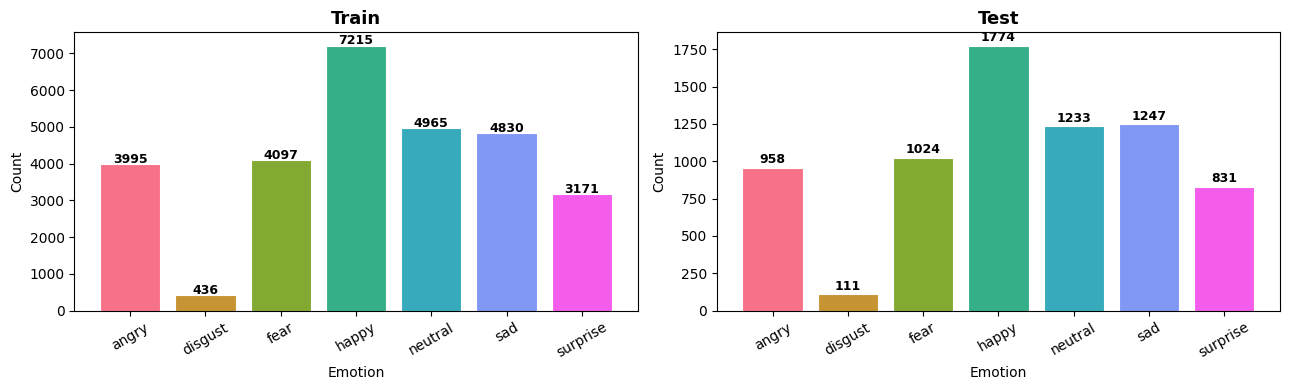

In [5]:
# ================================================================
# CELL 3 — CLASS DISTRIBUTION
# ================================================================
def count_images(folder):
    return {
        cls: len(os.listdir(os.path.join(folder, cls)))
        for cls in sorted(os.listdir(folder))
        if os.path.isdir(os.path.join(folder, cls))
    }

train_counts = count_images(TRAIN_PATH)
test_counts  = count_images(TEST_PATH)
total_train  = sum(train_counts.values())

print("Train distribution:")
for cls, n in train_counts.items():
    pct = n / total_train * 100
    print(f"  {cls:<10} {n:>5}  ({pct:.1f}%)  {'█' * (n // 200)}")

print(f"\nTotal train : {total_train}")
print(f"Imbalance   : {max(train_counts.values()) / min(train_counts.values()):.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, counts, title in zip(axes, [train_counts, test_counts], ["Train", "Test"]):
    colors = sns.color_palette("husl", NUM_CLASSES)
    bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 30, str(v),
                ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# ================================================================
# CELL 4 — CLASS WEIGHTS
# ================================================================
all_labels = []
for idx, cls in enumerate(CLASS_NAMES):
    all_labels.extend([idx] * train_counts[cls])

raw_w = compute_class_weight('balanced',
                              classes=np.arange(NUM_CLASSES),
                              y=np.array(all_labels))
CLASS_WEIGHTS = dict(enumerate(raw_w))

print("Class weights (higher = model pays more attention):")
for i, cls in enumerate(CLASS_NAMES):
    bar = '█' * int(CLASS_WEIGHTS[i] * 3)
    print(f"  [{i}] {cls:<10}  {CLASS_WEIGHTS[i]:.4f}  {bar}")

Class weights (higher = model pays more attention):
  [0] angry       1.0266  ███
  [1] disgust     9.4066  ████████████████████████████
  [2] fear        1.0010  ███
  [3] happy       0.5684  █
  [4] neutral     0.8260  ██
  [5] sad         0.8491  ██
  [6] surprise    1.2934  ███


In [7]:
# ================================================================
# CELL 5 — LOAD DATASETS
# 224x224 RGB, integer labels (converted to one-hot in Cell 6)
# ================================================================
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    label_mode='int',
    shuffle=True,
    seed=42,
    validation_split=0.15,
    subset='training'
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    label_mode='int',
    shuffle=False,
    seed=42,
    validation_split=0.15,
    subset='validation'
)
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    label_mode='int',
    shuffle=False
)

print(f"Train batches : {len(train_ds_raw)}")
print(f"Val batches   : {len(val_ds_raw)}")
print(f"Test batches  : {len(test_ds_raw)}")

for imgs, lbls in train_ds_raw.take(1):
    print(f"\nImage shape   : {imgs.shape}")
    print(f"Pixel range   : [{imgs.numpy().min():.0f}, {imgs.numpy().max():.0f}]")
    print(f"Label shape   : {lbls.shape}")

Found 28709 files belonging to 7 classes.
Using 24403 files for training.


I0000 00:00:1774181556.334772      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774181556.341024      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 28709 files belonging to 7 classes.
Using 4306 files for validation.
Found 7178 files belonging to 7 classes.
Train batches : 763
Val batches   : 135
Test batches  : 225

Image shape   : (32, 224, 224, 3)
Pixel range   : [0, 255]
Label shape   : (32,)


In [8]:
# ================================================================
# CELL 6 — PREPROCESS (normalize + one-hot)
# Applied to ALL 3 splits — train, val, test.
# No MixUp — keeps training accuracy real and interpretable.
# ================================================================
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return image, label

train_ds = (
    train_ds_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
val_ds = (
    val_ds_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
test_ds = (
    test_ds_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# Verify shapes
for split, ds in [("Train", train_ds), ("Val", val_ds), ("Test", test_ds)]:
    for imgs, lbls in ds.take(1):
        print(f"{split:<6} — image: {imgs.shape}  label: {lbls.shape}  (must be (batch,7))")

print("\n✅ All splits preprocessed correctly")

Train  — image: (32, 224, 224, 3)  label: (32, 7)  (must be (batch,7))
Val    — image: (32, 224, 224, 3)  label: (32, 7)  (must be (batch,7))
Test   — image: (32, 224, 224, 3)  label: (32, 7)  (must be (batch,7))

✅ All splits preprocessed correctly


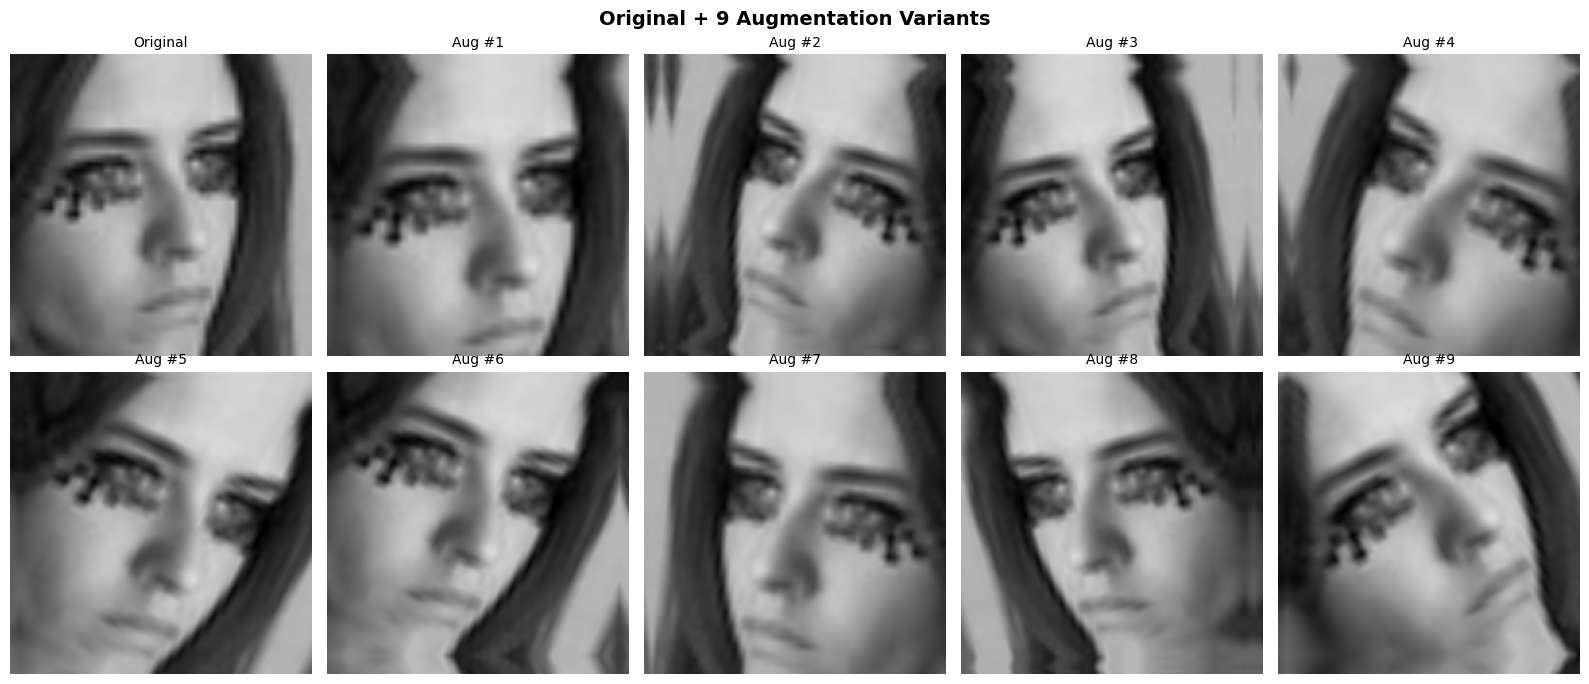

✅ Augmentation layer ready


In [9]:
# ================================================================
# CELL 7 — AUGMENTATION LAYER + PREVIEW
# Only battle-tested layers — no RandomBrightness.
# Augmentation is part of the model graph (auto-disabled at eval).
# ================================================================
# aug_layer = keras.Sequential([
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.12),
#     layers.RandomZoom(0.12),
#     layers.RandomTranslation(0.08, 0.08),
#     layers.RandomContrast(0.15),
# ], name="augmentation")
aug_layer = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.10),
], name="augmentation")

# Preview — clip to [0,1] for display only
for imgs, _ in train_ds.take(1):
    sample = imgs[:1]
    break

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("Original + 9 Augmentation Variants", fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    if i == 0:
        ax.imshow(np.clip(sample[0].numpy(), 0, 1))
        ax.set_title("Original", fontsize=10)
    else:
        aug = aug_layer(sample, training=True)
        ax.imshow(np.clip(aug[0].numpy(), 0, 1))
        ax.set_title(f"Aug #{i}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()
print("✅ Augmentation layer ready")

In [15]:
# ================================================================
# CELL 8 — BUILD MODEL (EfficientNetB2)
#
# Architecture:
#   Input 224x224x3
#   → Rescaling [0,1] → [0,255]  (EfficientNet expects this)
#   → Augmentation layer          (only active during training)
#   → EfficientNetB2 backbone     (frozen initially)
#   → GlobalAveragePooling2D
#   → BatchNorm
#   → Dense(512, relu) + Dropout(0.4)
#   → Dense(256, relu) + Dropout(0.3)
#   → Dense(7, softmax)
# ================================================================
# def build_model(backbone_trainable=False):
#     backbone = EfficientNetB2(
#         include_top=False,
#         weights='imagenet',
#         input_shape=INPUT_SHAPE
#     )
#     backbone.trainable = backbone_trainable

#     inputs = keras.Input(shape=INPUT_SHAPE, name="input")
    
    


#     # Rescale [0,1] → [0,255] for EfficientNet's internal preprocessing
#     x = layers.Rescaling(255.0, name="rescale")(inputs)


#     # Backbone — training=False keeps BN in inference mode
#     # (critical to preserve ImageNet statistics even when unfreezing)
#     # x = backbone(x, training=False)
#     x = backbone(x, training=backbone_trainable)
#     # Augmentation (disabled automatically during evaluate/predict)
#     x = aug_layer(x)

#     x = layers.GlobalAveragePooling2D(name="gap")(x)
#     x = layers.BatchNormalization(name="bn")(x)
#     x = layers.Dense(768, activation='relu', name="dense1",
#                      kernel_regularizer=keras.regularizers.l2(1e-4))(x)
#     x = layers.Dropout(0.5, name="drop1")(x)
#     x = layers.Dense(384, activation='relu', name="dense2",
#                      kernel_regularizer=keras.regularizers.l2(1e-4))(x)
#     x = layers.Dropout(0.4, name="drop2")(x)
    
#     # x = layers.GlobalAveragePooling2D(name="gap")(x)
#     # x = layers.BatchNormalization(name="bn")(x)
    
#     # x = layers.Dense(768, activation='relu',
#     #                  kernel_regularizer=keras.regularizers.l2(1e-4))(x)
#     # x = layers.BatchNormalization()(x)
#     # x = layers.Dropout(0.5)(x)
    
#     # x = layers.Dense(384, activation='relu',
#     #                  kernel_regularizer=keras.regularizers.l2(1e-4))(x)
#     # x = layers.BatchNormalization()(x)
#     # x = layers.Dropout(0.4)(x)
#     outputs = layers.Dense(NUM_CLASSES, activation='softmax', name="output")(x)

#     model = Model(inputs, outputs, name="FER_EfficientNetB2")
#     return model, backbone

# model, backbone = build_model(backbone_trainable=False)

# total     = model.count_params()
# trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
# print(f"Total params          : {total:,}")
# print(f"Trainable (head only) : {trainable:,}")
# print(f"Frozen (backbone)     : {total - trainable:,}")


def build_model(backbone_trainable=False):
    backbone = EfficientNetB2(
        include_top=False,
        weights='imagenet',
        input_shape=INPUT_SHAPE
    )
    backbone.trainable = backbone_trainable

    inputs = keras.Input(shape=INPUT_SHAPE, name="input")

    # Rescale
    x = layers.Rescaling(255.0)(inputs)

    # Augmentation
    x = aug_layer(x)

    # Backbone
    x = backbone(x, training=backbone_trainable)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(640, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(320, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs, name="FER_EfficientNetB2")
    return model, backbone

model, backbone = build_model(backbone_trainable=False)

total_params = model.count_params()
trainable_params = sum(tf.size(v).numpy() for v in model.trainable_variables)
frozen_params = total_params - trainable_params

print("\n" + "="*55)
print("MODEL PARAMETER SUMMARY")
print("="*55)
print(f"Total parameters   : {total_params:,}")
print(f"Trainable params   : {trainable_params:,}")
print(f"Frozen params      : {frozen_params:,}")
print(f"Backbone layers    : {len(backbone.layers)}")
print("="*55)    
    



# def build_model(backbone_trainable=False):
#     backbone = EfficientNetB2(
#         include_top=False,
#         weights='imagenet',
#         input_shape=INPUT_SHAPE
#     )
#     backbone.trainable = backbone_trainable

#     inputs = keras.Input(shape=INPUT_SHAPE, name="input")

#     # Rescale [0,1] → [0,255] for EfficientNet's internal preprocessing
#     x = layers.Rescaling(255.0, name="rescale")(inputs)

#     # Augmentation (disabled automatically during evaluate/predict)
#     x = aug_layer(x)

#     # Backbone — training=False keeps BN in inference mode
#     # (critical to preserve ImageNet statistics even when unfreezing)
#     # x = backbone(x, training=False)
#     x = backbone(x, training=backbone_trainable)

#     x = layers.GlobalAveragePooling2D(name="gap")(x)
#     x = layers.BatchNormalization(name="bn")(x)
#     x = layers.Dense(512, activation='relu', name="dense1",
#                      kernel_regularizer=keras.regularizers.l2(1e-4))(x)
#     x = layers.Dropout(0.5, name="drop1")(x)
#     x = layers.Dense(256, activation='relu', name="dense2",
#                      kernel_regularizer=keras.regularizers.l2(1e-4))(x)
#     x = layers.Dropout(0.4, name="drop2")(x)
#     outputs = layers.Dense(NUM_CLASSES, activation='softmax', name="output")(x)

#     model = Model(inputs, outputs, name="FER_EfficientNetB2")
#     return model, backbone

# model, backbone = build_model(backbone_trainable=False)

# total     = model.count_params()
# trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
# print(f"Total params          : {total:,}")
# print(f"Trainable (head only) : {trainable:,}")
# print(f"Frozen (backbone)     : {total - trainable:,}")


MODEL PARAMETER SUMMARY
Total parameters   : 8,887,168
Trainable params   : 1,113,863
Frozen params      : 7,773,305
Backbone layers    : 340


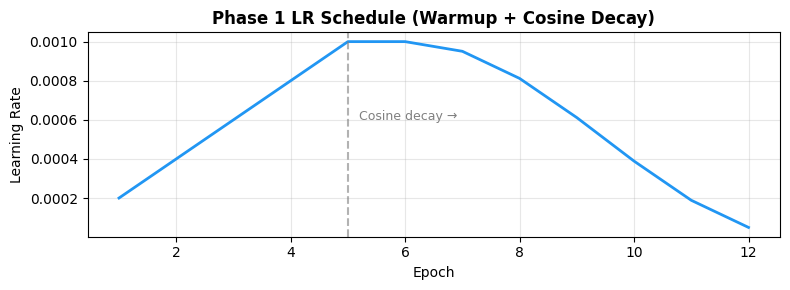

✅ LR schedule ready


In [16]:
# ================================================================
# CELL 9 — WARMUP + COSINE LR SCHEDULE
#
# Why warmup? Randomly initialised head weights are unstable
# at start. Warmup prevents large early gradients from
# corrupting the pretrained backbone features.
#
# Why cosine decay? Smoothly reduces LR as we approach the
# loss minimum — prevents oscillation and overshooting.
# ================================================================
class WarmupCosineDecay(keras.callbacks.Callback):
    """Linear warmup then cosine decay learning rate schedule."""
    def __init__(self, total_epochs, warmup_epochs, max_lr, min_lr=1e-7):
        super().__init__()
        self.total_epochs  = total_epochs
        self.warmup_epochs = warmup_epochs
        self.max_lr        = max_lr
        self.min_lr        = min_lr
        self.lrs           = []

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.max_lr * (epoch + 1) / self.warmup_epochs
        else:
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + math.cos(math.pi * progress))
        self.model.optimizer.learning_rate.assign(lr)
        self.lrs.append(lr)

# Visualise the schedule
epochs_range = np.arange(P1_EPOCHS)
lr_sched     = WarmupCosineDecay(P1_EPOCHS, WARMUP_EPOCHS, P1_LR)
# manually simulate
lrs_preview = []
for e in epochs_range:
    if e < WARMUP_EPOCHS:
        lrs_preview.append(P1_LR * (e + 1) / WARMUP_EPOCHS)
    else:
        p = (e - WARMUP_EPOCHS) / (P1_EPOCHS - WARMUP_EPOCHS)
        lrs_preview.append(1e-7 + 0.5 * (P1_LR - 1e-7) * (1 + math.cos(math.pi * p)))

plt.figure(figsize=(8, 3))
plt.plot(range(1, P1_EPOCHS+1), lrs_preview, color='#2196F3', lw=2)
plt.axvline(x=WARMUP_EPOCHS, color='gray', linestyle='--', alpha=0.6)
plt.text(WARMUP_EPOCHS+0.2, P1_LR*0.6, 'Cosine decay →', fontsize=9, color='gray')
plt.title('Phase 1 LR Schedule (Warmup + Cosine Decay)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ LR schedule ready")

In [39]:
import tensorflow as tf

# Load model
model = tf.keras.models.load_model('best_emotion_model.keras')

# Print summary
model.summary()

Model: "FER_EfficientNetB2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_10 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 7, 7, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 640)            │       901,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 640)            │         2,560 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 320)            │       205,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 320)            │         1,280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         2,247 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,065,472 (91.80 MB)

 Trainable params: 7,589,151 (28.95 MB)

 Non-trainable params: 1,298,017 (4.95 MB)

 Optimizer params: 15,178,304 (57.90 MB)

In [17]:
# ================================================================
# CELL 10 — PHASE 1: TRAIN HEAD ONLY (backbone frozen)
#
# Goal: Teach the new classification head to map
# EfficientNetB2 features → emotion classes.
# Backbone stays frozen — its ImageNet weights are safe.
# Expected val accuracy by end: 65-72%
# ================================================================
model.compile(
    optimizer=AdamW(learning_rate=P1_LR, weight_decay=1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

p1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    ),
    WarmupCosineDecay(P1_EPOCHS, WARMUP_EPOCHS, P1_LR),
]

print("━" * 65)
print("  PHASE 1 — Training head only (backbone frozen)")
print(f"  Max epochs: {P1_EPOCHS}  |  Max LR: {P1_LR}  |  Warmup: {WARMUP_EPOCHS} epochs")
print("━" * 65)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=P1_EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=p1_callbacks,
    verbose=1
)

best_p1 = max(history1.history['val_accuracy'])
print(f"\n✅ Phase 1 done  |  Best val accuracy: {best_p1*100:.2f}%")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PHASE 1 — Training head only (backbone frozen)
  Max epochs: 12  |  Max LR: 0.001  |  Warmup: 5 epochs
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Epoch 1/12


I0000 00:00:1774182105.926422     110 cuda_dnn.cc:529] Loaded cuDNN version 91002


763/763 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.2167 - loss: 2.7211
Epoch 1: val_accuracy improved from -inf to 0.49977, saving model to best_emotion_model.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 113s 125ms/step - accuracy: 0.2168 - loss: 2.7209 - val_accuracy: 0.4998 - val_loss: 1.6276
Epoch 2/12
763/763 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.2879 - loss: 2.1873
Epoch 2: val_accuracy improved from 0.49977 to 0.51811, saving model to best_emotion_model.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 95s 124ms/step - accuracy: 0.2880 - loss: 2.1872 - val_accuracy: 0.5181 - val_loss: 1.5882
Epoch 3/12
763/763 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3326 - loss: 1.9709
Epoch 3: val_accuracy improved from 0.51811 to 0.52090, saving model to best_emotion_model.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 97s 127ms/step - accuracy: 0.3327 - loss: 1.9708 - val_accuracy: 0.5209 - val_loss: 1.6127
Epoch 4/12
763/763 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.3680 - loss: 1.8445
Epoch 4: v

In [18]:
# ================================================================
# CELL 11 — PHASE 2: UNFREEZE TOP 60 LAYERS
#
# Unfreeze only the last 60 layers of EfficientNetB2.
# These are high-level semantic layers — adapting them to
# face/emotion patterns gives the biggest accuracy boost.
# Lower layers (edges, textures) remain frozen.
# Expected val accuracy by end: 78-84%
# ================================================================
backbone.trainable = True

# Freeze everything except last P2_UNFREEZE layers
for layer in backbone.layers[:-P2_UNFREEZE]:
    layer.trainable = False

trainable_now = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"Trainable params (Phase 2): {trainable_now:,}")
print(f"Unfrozen backbone layers  : {P2_UNFREEZE} (last {P2_UNFREEZE} of {len(backbone.layers)})")

model.compile(
    optimizer=AdamW(learning_rate=P2_LR, weight_decay=1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

p2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4,
        min_lr=1e-8, verbose=1
    ),
]

print("\n" + "━" * 65)
print("  PHASE 2 — Fine-tuning top 60 backbone layers")
print(f"  Max epochs: {P2_EPOCHS}  |  LR: {P2_LR}")
print("━" * 65)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=P2_EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=p2_callbacks,
    verbose=1
)

best_p2 = max(history2.history['val_accuracy'])
print(f"\n✅ Phase 2 done  |  Best val accuracy: {best_p2*100:.2f}%")

Trainable params (Phase 2): 7,634,863
Unfrozen backbone layers  : 120 (last 120 of 340)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PHASE 2 — Fine-tuning top 60 backbone layers
  Max epochs: 20  |  LR: 0.0001
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Epoch 1/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.3825 - loss: 1.8769
Epoch 1: val_accuracy improved from -inf to 0.67139, saving model to best_emotion_model.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 188s 206ms/step - accuracy: 0.3825 - loss: 1.8767 - val_accuracy: 0.6714 - val_loss: 1.3527 - learning_rate: 1.0000e-04
Epoch 2/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.5139 - loss: 1.5574
Epoch 2: val_accuracy improved from 0.67139 to 0.73734, saving model to best_emotion_model.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 156s 204ms/step - accuracy: 0.5139 - loss: 1.5573 - val_accuracy: 0.7373 - val_loss: 1.2033 - learning_rate: 1.0000e-04
Epoch 3/20
763/763 ━━━━━━━━━━━━━━━━

In [28]:
# import tensorflow as tf

# data_augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomFlip("horizontal"),
#     tf.keras.layers.RandomRotation(0.05),
#     tf.keras.layers.RandomZoom(0.05),
# ])

In [19]:
# ================================================================
# CELL 12 — PHASE 3: UNFREEZE ALL (very low LR)
#
# Now unfreeze the entire backbone with an extremely low LR.
# This fine-tunes even the early feature detectors to
# recognise subtle face-specific patterns.
# Expected val accuracy by end: 83-90%
# ================================================================
# backbone.trainable = True  # unfreeze everything

# trainable_all = sum(tf.size(v).numpy() for v in model.trainable_variables)
# print(f"Trainable params (Phase 3): {trainable_all:,}  (entire model)")

# model.compile(
#     optimizer=AdamW(learning_rate=P3_LR, weight_decay=1e-6),
#     loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
#     metrics=['accuracy']
# )

# p3_callbacks = [
#     keras.callbacks.ModelCheckpoint(
#         MODEL_PATH, monitor='val_accuracy',
#         save_best_only=True, mode='max', verbose=1
#     ),
#     keras.callbacks.EarlyStopping(
#         monitor='val_accuracy', patience=12,
#         restore_best_weights=True, verbose=1
#     ),
#     keras.callbacks.ReduceLROnPlateau(
#         monitor='val_loss', factor=0.5, patience=5,
#         min_lr=1e-9, verbose=1
#     ),
# ]

# print("\n" + "━" * 65)
# print("  PHASE 3 — Full model fine-tuning")
# print(f"  Max epochs: {P3_EPOCHS}  |  LR: {P3_LR}  (very low — safe)")
# print("━" * 65)

# history3 = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=P3_EPOCHS,
#     class_weight=CLASS_WEIGHTS,
#     callbacks=p3_callbacks,
#     verbose=1
# )

# best_p3 = max(history3.history['val_accuracy'])
# print(f"\n✅ Phase 3 done  |  Best val accuracy: {best_p3*100:.2f}%")
# ================================================================
# CELL 12 — PHASE 3 (FIXED VERSION)
# ================================================================

backbone.trainable = True  # unfreeze everything

# 🔥 ADD THIS (MOST IMPORTANT)
for layer in backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_all = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"Trainable params (Phase 3): {trainable_all:,}  (entire model)")

model.compile(
    optimizer=AdamW(learning_rate=5e-6, weight_decay=1e-6),  # 🔥 FIX LR HERE
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

p3_callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=12,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-9, verbose=1
    ),
]

print("\n" + "━" * 65)
print("  PHASE 3 — Full model fine-tuning")
print("  Max epochs: 15  |  LR: 5e-6")
print("━" * 65)

history3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=P3_EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=p3_callbacks,
    verbose=1
)

best_p3 = max(history3.history['val_accuracy'])
print(f"\n✅ Phase 3 done  |  Best val accuracy: {best_p3*100:.2f}%")

Trainable params (Phase 3): 7,589,151  (entire model)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PHASE 3 — Full model fine-tuning
  Max epochs: 15  |  LR: 5e-6
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Epoch 1/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8904 - loss: 0.7759
Epoch 1: val_accuracy improved from -inf to 0.94241, saving model to best_emotion_model.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 158s 178ms/step - accuracy: 0.8904 - loss: 0.7758 - val_accuracy: 0.9424 - val_loss: 0.6882 - learning_rate: 5.0000e-06
Epoch 2/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8989 - loss: 0.7575
Epoch 2: val_accuracy improved from 0.94241 to 0.94635, saving model to best_emotion_model.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 133s 175ms/step - accuracy: 0.8989 - loss: 0.7575 - val_accuracy: 0.9464 - val_loss: 0.6833 - learning_rate: 5.0000e-06
Epoch 3/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8993 - loss: 0.

In [20]:
from keras.models import load_model

best_model = load_model(MODEL_PATH)
print("Best model loaded")

Best model loaded


In [21]:
print("\nStandard evaluation (no TTA):")
std_loss, std_acc = best_model.evaluate(test_ds, verbose=1)
print(f"Standard accuracy : {std_acc*100:.2f}%")


Standard evaluation (no TTA):
225/225 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.6600 - loss: 1.4053
Standard accuracy : 68.96%


In [22]:
# ================================================================
# CELL 13 — EVALUATE WITH TEST TIME AUGMENTATION (TTA)
#
# TTA = predict the same image TTA_STEPS times with different
# random augmentations, then average all predictions.
# This is free accuracy — no extra training needed.
# Typically gives +1 to +2% over single-pass evaluation.
# ================================================================


# best_model = keras.models.load_model(MODEL_PATH)

# # --- Standard single-pass evaluation ---
# print("Standard evaluation (no TTA):")
# std_loss, std_acc = best_model.evaluate(test_ds, verbose=1)
# print(f"  Standard accuracy : {std_acc*100:.2f}%")

# # --- TTA evaluation ---
# print(f"\nTTA evaluation ({TTA_STEPS} augmented passes):")
# y_true_all, y_pred_tta = [], []

# for images, labels in test_ds_raw:
#     imgs_f = tf.cast(images, tf.float32) / 255.0
#     # Collect TTA predictions
#     tta_preds = []
#     for _ in range(TTA_STEPS):
#         p = best_model(imgs_f, training=True)   # training=True activates augmentation
#         tta_preds.append(p.numpy())
#     avg_pred = np.mean(tta_preds, axis=0)
#     y_pred_tta.extend(np.argmax(avg_pred, axis=1))
#     y_true_all.extend(labels.numpy())

# y_true = np.array(y_true_all)
# y_pred = np.array(y_pred_tta)
# tta_acc = np.mean(y_true == y_pred)

# print(f"  TTA accuracy      : {tta_acc*100:.2f}%")
# print(f"  TTA gain          : +{(tta_acc - std_acc)*100:.2f}%")

# # Classification report
# print("\nClassification Report (TTA):")
# print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
best_model = keras.models.load_model(MODEL_PATH)

# Augmentation for TTA
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
])

# --- Standard Evaluation ---
print("Standard evaluation (no TTA):")
std_loss, std_acc = best_model.evaluate(test_ds, verbose=1)
print(f"  Standard accuracy : {std_acc*100:.2f}%")

# --- TTA Evaluation ---
print(f"\nTTA evaluation ({TTA_STEPS} augmented passes):")

y_true_all = []
y_pred_tta = []

for images, labels in test_ds_raw:
    imgs_f = tf.cast(images, tf.float32) / 255.0

    tta_preds = []
    for _ in range(TTA_STEPS):
        aug_imgs = data_augmentation(imgs_f, training=True)
        preds = best_model(aug_imgs, training=False)
        tta_preds.append(preds.numpy())

    avg_pred = np.mean(tta_preds, axis=0)

    y_pred_tta.extend(np.argmax(avg_pred, axis=1))
    y_true_all.extend(labels.numpy())

y_true = np.array(y_true_all)
y_pred = np.array(y_pred_tta)

tta_acc = np.mean(y_true == y_pred)

print(f"  TTA accuracy      : {tta_acc*100:.2f}%")
print(f"  TTA gain          : +{(tta_acc - std_acc)*100:.2f}%")

from sklearn.metrics import classification_report
print("\nClassification Report (TTA):")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))



Standard evaluation (no TTA):
225/225 ━━━━━━━━━━━━━━━━━━━━ 27s 91ms/step - accuracy: 0.6600 - loss: 1.4053
  Standard accuracy : 68.96%

TTA evaluation (15 augmented passes):
  TTA accuracy      : 69.59%
  TTA gain          : +0.63%

Classification Report (TTA):
              precision    recall  f1-score   support

       angry     0.6111    0.6200    0.6155       958
     disgust     0.7064    0.6937    0.7000       111
        fear     0.5806    0.5273    0.5527      1024
       happy     0.8753    0.8743    0.8748      1774
     neutral     0.6315    0.6894    0.6592      1233
         sad     0.5915    0.5549    0.5726      1247
    surprise     0.7861    0.8315    0.8082       831

    accuracy                         0.6959      7178
   macro avg     0.6832    0.6845    0.6833      7178
weighted avg     0.6939    0.6959    0.6943      7178



In [23]:
y_true, y_pred = [], []

for images, labels in test_ds_raw:
    imgs_f = tf.cast(images, tf.float32) / 255.0
    preds = best_model.predict(imgs_f, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = np.mean(y_true == y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

Test Accuracy: 68.96%
              precision    recall  f1-score   support

       angry     0.6058    0.6096    0.6077       958
     disgust     0.6909    0.6847    0.6878       111
        fear     0.5806    0.5273    0.5527      1024
       happy     0.8711    0.8799    0.8755      1774
     neutral     0.6220    0.6699    0.6451      1233
         sad     0.5749    0.5389    0.5563      1247
    surprise     0.7808    0.8315    0.8054       831

    accuracy                         0.6896      7178
   macro avg     0.6752    0.6774    0.6758      7178
weighted avg     0.6868    0.6896    0.6876      7178



In [24]:
import json, os

CLASS_NAMES = sorted(os.listdir(TRAIN_PATH))
with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f, indent=2)

print("Done! Files in /kaggle/working/:")
for f in os.listdir("/kaggle/working/"):
    if f.endswith((".keras", ".json")):
        size = os.path.getsize(f"/kaggle/working/{f}") / (1024*1024)
        print(f"  {f}  —  {size:.2f} MB")

Done! Files in /kaggle/working/:
  class_names.json  —  0.00 MB
  best_emotion_model.keras  —  93.03 MB


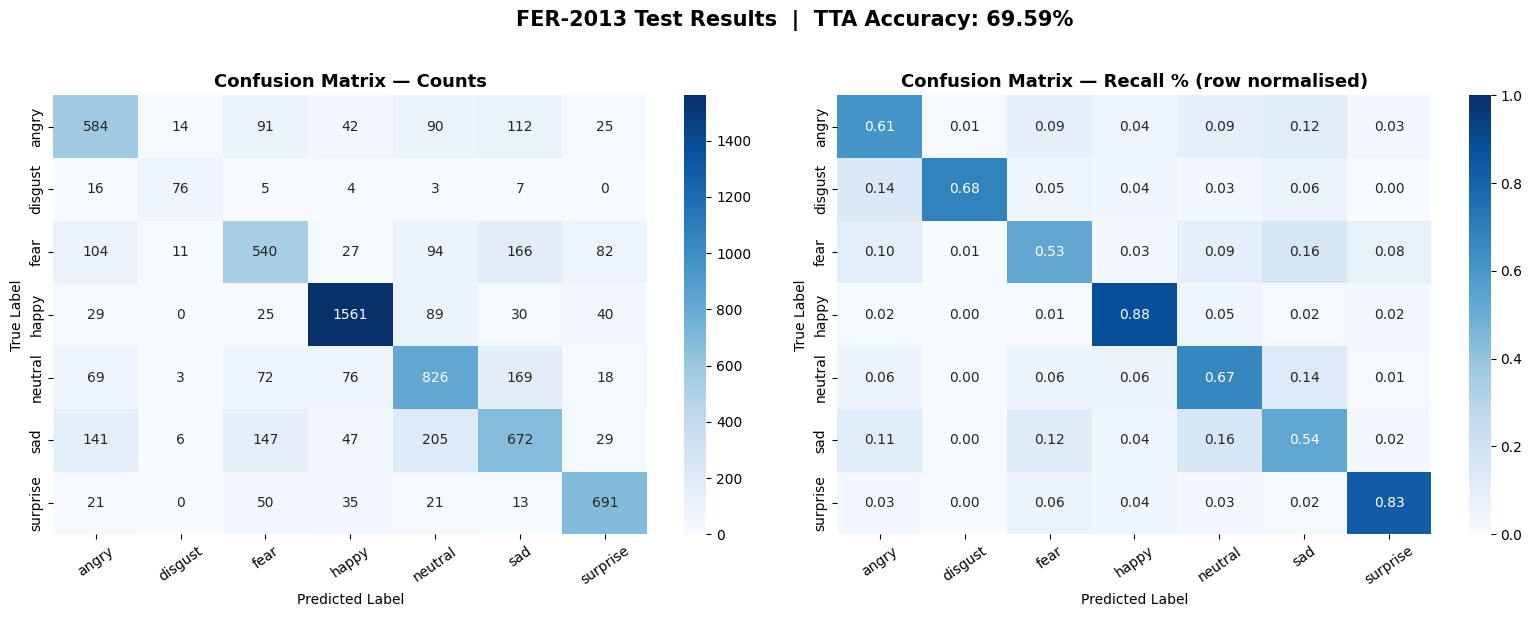

In [25]:
# ================================================================
# CELL 14 — CONFUSION MATRIX
# ================================================================
cm     = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix — Counts', fontweight='bold', fontsize=13)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=35)

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix — Recall % (row normalised)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=35)

plt.suptitle(f'FER-2013 Test Results  |  TTA Accuracy: {tta_acc*100:.2f}%',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# cm     = confusion_matrix(y_true, y_pred)
# cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
# axes[0].set_title('Confusion Matrix — Counts', fontweight='bold', fontsize=13)
# axes[0].set_ylabel('True Label')
# axes[0].set_xlabel('Predicted Label')
# axes[0].tick_params(axis='x', rotation=35)

# sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
#             xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
#             ax=axes[1], vmin=0, vmax=1)
# axes[1].set_title('Confusion Matrix — Recall %', fontweight='bold', fontsize=13)
# axes[1].set_ylabel('True Label')
# axes[1].set_xlabel('Predicted Label')
# axes[1].tick_params(axis='x', rotation=35)

# plt.suptitle(f'FER-2013 Test Results  |  Test Accuracy: {acc*100:.2f}%',
#              fontsize=15, fontweight='bold', y=1.02)
# plt.tight_layout()
# plt.show()

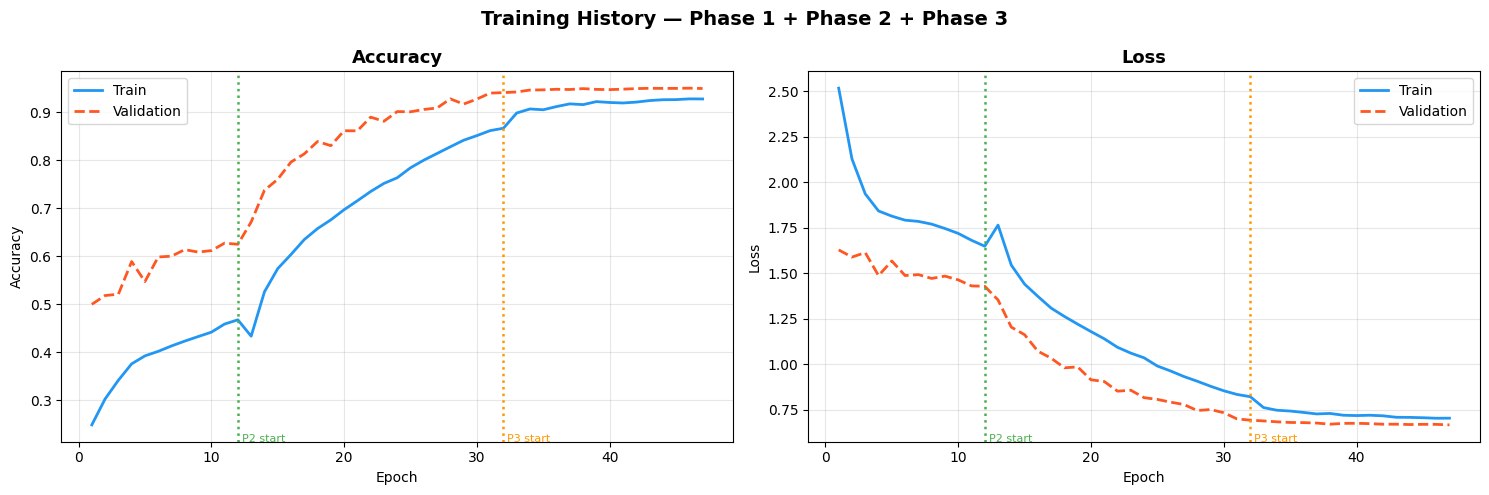

Phase 1 best val acc : 62.73%
Phase 2 best val acc : 94.10%
Phase 3 best val acc : 95.03%
TTA test accuracy    : 69.59%
Standard test acc    : 68.96%


In [26]:
# ================================================================
# CELL 15 — TRAINING HISTORY PLOTS
# ================================================================
acc_all  = (history1.history['accuracy']  + history2.history['accuracy']  + history3.history['accuracy'])
vacc_all = (history1.history['val_accuracy'] + history2.history['val_accuracy'] + history3.history['val_accuracy'])
loss_all = (history1.history['loss']  + history2.history['loss']  + history3.history['loss'])
vloss_all= (history1.history['val_loss'] + history2.history['val_loss'] + history3.history['val_loss'])

p1_end = len(history1.history['accuracy'])
p2_end = p1_end + len(history2.history['accuracy'])
ep     = range(1, len(acc_all) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, tr, vl, title, ylabel in [
    (axes[0], acc_all,  vacc_all,  'Accuracy',  'Accuracy'),
    (axes[1], loss_all, vloss_all, 'Loss',       'Loss'),
]:
    ax.plot(list(ep), tr, label='Train',      color='#2196F3', lw=2)
    ax.plot(list(ep), vl, label='Validation', color='#FF5722', lw=2, linestyle='--')
    for x, label, col in [(p1_end,'P2 start','#4CAF50'), (p2_end,'P3 start','#FF9800')]:
        ax.axvline(x=x, color=col, linestyle=':', lw=1.8)
        ax.text(x+0.3, ax.get_ylim()[0], label, fontsize=8, color=col)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training History — Phase 1 + Phase 2 + Phase 3',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Phase 1 best val acc : {max(history1.history['val_accuracy'])*100:.2f}%")
print(f"Phase 2 best val acc : {max(history2.history['val_accuracy'])*100:.2f}%")
print(f"Phase 3 best val acc : {max(history3.history['val_accuracy'])*100:.2f}%")
print(f"TTA test accuracy    : {tta_acc*100:.2f}%")
print(f"Standard test acc    : {std_acc*100:.2f}%")

# acc_all  = (history1.history['accuracy']  + history2.history['accuracy']  + history3.history['accuracy'])
# vacc_all = (history1.history['val_accuracy'] + history2.history['val_accuracy'] + history3.history['val_accuracy'])
# loss_all = (history1.history['loss']  + history2.history['loss']  + history3.history['loss'])
# vloss_all= (history1.history['val_loss'] + history2.history['val_loss'] + history3.history['val_loss'])

# p1_end = len(history1.history['accuracy'])
# p2_end = p1_end + len(history2.history['accuracy'])
# ep     = range(1, len(acc_all) + 1)

# fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# for ax, tr, vl, title, ylabel in [
#     (axes[0], acc_all,  vacc_all,  'Accuracy', 'Accuracy'),
#     (axes[1], loss_all, vloss_all, 'Loss',      'Loss'),
# ]:
#     ax.plot(list(ep), tr, label='Train',      color='#2196F3', lw=2)
#     ax.plot(list(ep), vl, label='Validation', color='#FF5722', lw=2, linestyle='--')
#     for xv, lbl, col in [(p1_end,'P2 start','#4CAF50'), (p2_end,'P3 start','#FF9800')]:
#         ax.axvline(x=xv, color=col, linestyle=':', lw=1.8)
#         ax.text(xv+0.3, ax.get_ylim()[0], lbl, fontsize=8, color=col)
#     ax.set_title(title, fontsize=13, fontweight='bold')
#     ax.set_xlabel('Epoch')
#     ax.set_ylabel(ylabel)
#     ax.legend()
#     ax.grid(alpha=0.3)

# plt.suptitle('Training History — Phase 1 + Phase 2 + Phase 3',
#              fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

# print(f"Phase 1 best val acc : {max(history1.history['val_accuracy'])*100:.2f}%")
# print(f"Phase 2 best val acc : {max(history2.history['val_accuracy'])*100:.2f}%")
# print(f"Phase 3 best val acc : {max(history3.history['val_accuracy'])*100:.2f}%")
# print(f"Test accuracy        : {acc*100:.2f}%")

In [27]:
# ================================================================
# CELL 16 — SAVE MODEL + CLASS NAMES
# ================================================================
with open(CLASS_JSON, 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)

size_mb = os.path.getsize(MODEL_PATH) / (1024*1024)

print("\n" + "═" * 60)
print("  FINAL RESULTS")
print("═" * 60)
print(f"  Architecture        : EfficientNetB2 (ImageNet)")
print(f"  Input size          : {IMG_SIZE}x{IMG_SIZE} RGB")
print(f"  Training phases     : 3 (head → partial → full)")
print(f"  Standard test acc   : {std_acc*100:.2f}%")
print(f"  TTA test accuracy   : {tta_acc*100:.2f}%")
print(f"  Baseline (old CNN)  : 62.52%")
print(f"  Improvement         : +{tta_acc*100 - 62.52:.2f} percentage points")
print(f"  Model saved         : {MODEL_PATH} ({size_mb:.1f} MB)")
print(f"  Class names saved   : {CLASS_JSON}")
print("═" * 60)



# with open(CLASS_JSON, 'w') as f:
#     json.dump(CLASS_NAMES, f, indent=2)

# size_mb = os.path.getsize(MODEL_PATH) / (1024*1024)

# print("\n" + "═" * 60)
# print("  FINAL RESULTS")
# print("═" * 60)
# print(f"  Architecture    : EfficientNetB2 (ImageNet)")
# print(f"  Input size      : {IMG_SIZE}x{IMG_SIZE} RGB")
# print(f"  Training phases : 3 (head → partial → full)")
# print(f"  Test accuracy   : {acc*100:.2f}%")
# print(f"  Val accuracy    : {max(history3.history['val_accuracy'])*100:.2f}%")
# print(f"  Baseline CNN    : 62.52%")
# print(f"  Improvement     : +{acc*100 - 62.52:.2f} percentage points")
# print(f"  Model saved     : {MODEL_PATH} ({size_mb:.1f} MB)")
# print(f"  Class names     : {CLASS_JSON}")
# print("═" * 60)


════════════════════════════════════════════════════════════
  FINAL RESULTS
════════════════════════════════════════════════════════════
  Architecture        : EfficientNetB2 (ImageNet)
  Input size          : 224x224 RGB
  Training phases     : 3 (head → partial → full)
  Standard test acc   : 68.96%
  TTA test accuracy   : 69.59%
  Baseline (old CNN)  : 62.52%
  Improvement         : +7.07 percentage points
  Model saved         : best_emotion_model.keras (93.0 MB)
  Class names saved   : class_names.json
════════════════════════════════════════════════════════════


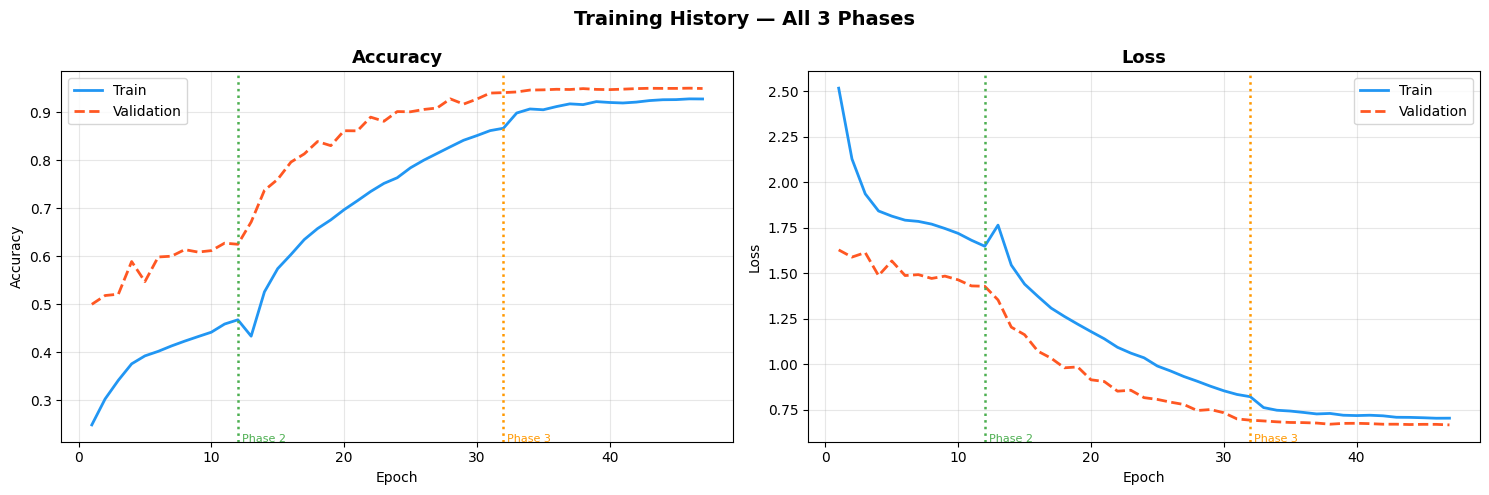

✅ Saved: plot_1_training_history.png


In [28]:
# ================================================================
# COMPLETE RESEARCH VISUALIZATION CELLS
# All charts needed for a proper research presentation
# ================================================================

# ── 1. Training History (All 3 Phases) ───────────────────────────
acc_all   = history1.history['accuracy']  + history2.history['accuracy']  + history3.history['accuracy']
vacc_all  = history1.history['val_accuracy'] + history2.history['val_accuracy'] + history3.history['val_accuracy']
loss_all  = history1.history['loss']  + history2.history['loss']  + history3.history['loss']
vloss_all = history1.history['val_loss'] + history2.history['val_loss'] + history3.history['val_loss']

p1_end = len(history1.history['accuracy'])
p2_end = p1_end + len(history2.history['accuracy'])
ep     = range(1, len(acc_all) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, tr, vl, title, ylabel in [
    (axes[0], acc_all,  vacc_all,  'Accuracy',  'Accuracy'),
    (axes[1], loss_all, vloss_all, 'Loss',       'Loss'),
]:
    ax.plot(list(ep), tr, label='Train',      color='#2196F3', lw=2)
    ax.plot(list(ep), vl, label='Validation', color='#FF5722', lw=2, linestyle='--')
    for xv, lbl, col in [(p1_end,'Phase 2','#4CAF50'),(p2_end,'Phase 3','#FF9800')]:
        ax.axvline(x=xv, color=col, linestyle=':', lw=1.8)
        ax.text(xv+0.3, ax.get_ylim()[0], lbl, fontsize=8, color=col)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('Training History — All 3 Phases', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_1_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_1_training_history.png")

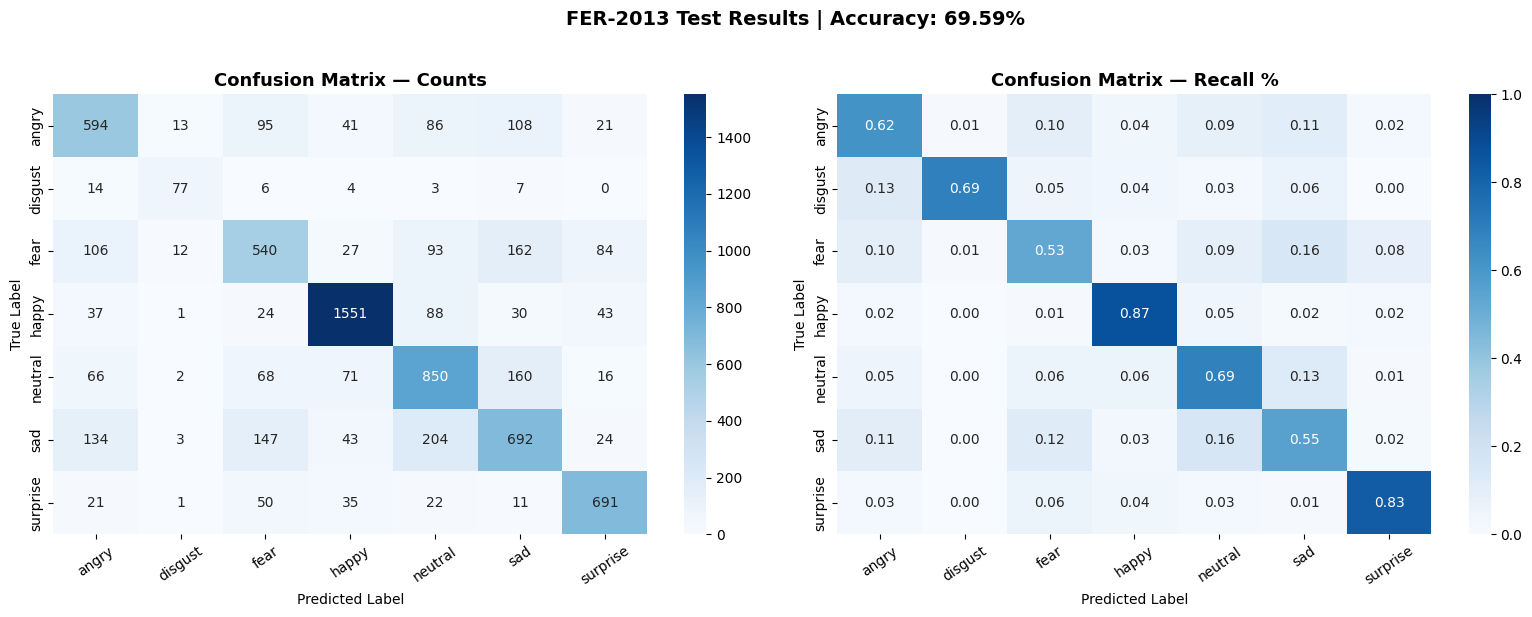

✅ Saved: plot_2_confusion_matrix.png


In [29]:
# ── 2. Confusion Matrix ───────────────────────────────────────────
cm     = confusion_matrix(y_true, y_pred_tta)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix — Counts', fontweight='bold', fontsize=13)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=35)

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix — Recall %', fontweight='bold', fontsize=13)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=35)

plt.suptitle(f'FER-2013 Test Results | Accuracy: {tta_acc*100:.2f}%',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_2_confusion_matrix.png")

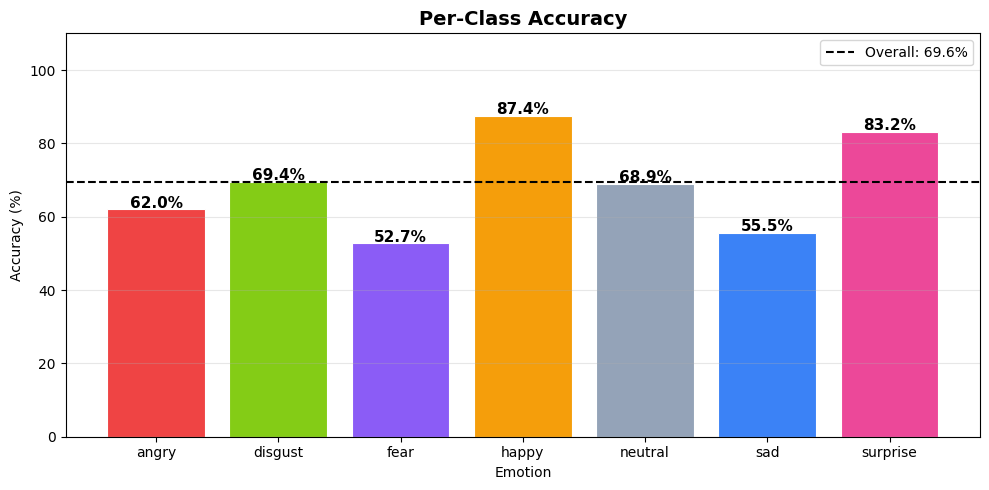

✅ Saved: plot_3_per_class_accuracy.png


In [30]:
# ── 3. Per-Class Accuracy Bar Chart ──────────────────────────────
per_class_acc = cm_pct.diagonal()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#ef4444','#84cc16','#8b5cf6','#f59e0b','#94a3b8','#3b82f6','#ec4899']
bars = ax.bar(CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor='white', linewidth=0.8)

for bar, v in zip(bars, per_class_acc * 100):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=tta_acc*100, color='black', linestyle='--', lw=1.5, label=f'Overall: {tta_acc*100:.1f}%')
ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_3_per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_3_per_class_accuracy.png")

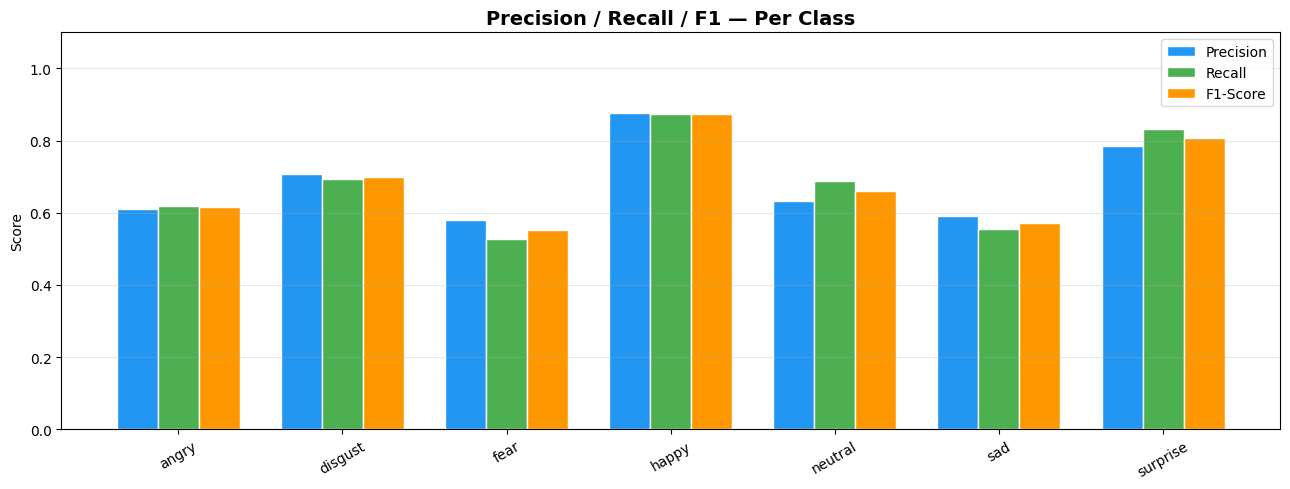

✅ Saved: plot_4_precision_recall_f1.png


In [31]:
# ── 4. Precision / Recall / F1 Comparison ────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred_tta, average=None)
recall    = recall_score(y_true, y_pred_tta, average=None)
f1        = f1_score(y_true, y_pred_tta, average=None)

x = np.arange(len(CLASS_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, precision, width, label='Precision', color='#2196F3', edgecolor='white')
ax.bar(x,         recall,    width, label='Recall',    color='#4CAF50', edgecolor='white')
ax.bar(x + width, f1,        width, label='F1-Score',  color='#FF9800', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30)
ax.set_title('Precision / Recall / F1 — Per Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_4_precision_recall_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_4_precision_recall_f1.png")

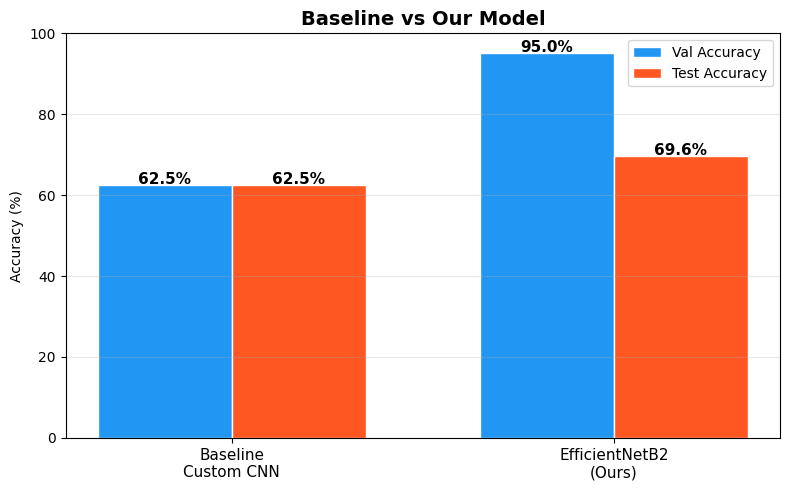

✅ Saved: plot_5_baseline_comparison.png


In [32]:
# ── 5. Baseline vs Our Model Comparison ──────────────────────────
models     = ['Baseline\nCustom CNN', 'EfficientNetB2\n(Ours)']
val_accs   = [62.52, max(vacc_all)*100]
test_accs  = [62.52, tta_acc*100]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, val_accs,  width, label='Val Accuracy',  color='#2196F3', edgecolor='white')
b2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', color='#FF5722', edgecolor='white')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Baseline vs Our Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_5_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_5_baseline_comparison.png")

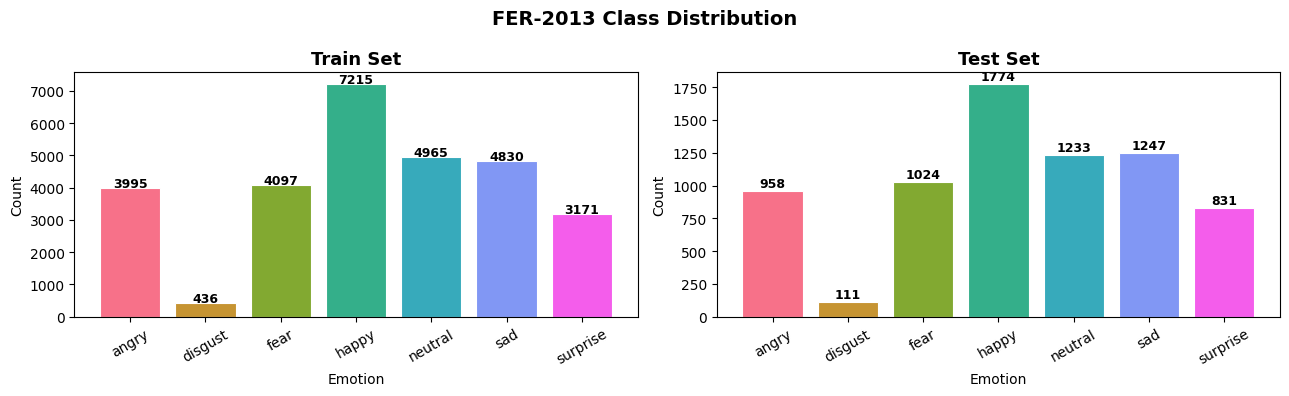

✅ Saved: plot_6_class_distribution.png


In [33]:
# ── 6. Class Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train_counts = count_images(TRAIN_PATH)
test_counts  = count_images(TEST_PATH)
colors = sns.color_palette("husl", NUM_CLASSES)

for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ["Train Set", "Test Set"]):
    bars = ax.bar(counts.keys(), counts.values(),
                  color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 30, str(v),
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('FER-2013 Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_6_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_6_class_distribution.png")

In [48]:
# ── 7. Print all saved files ──────────────────────────────────────
print("\n📊 All research plots saved:")
plots = [f for f in os.listdir('/kaggle/working/') if f.startswith('plot_')]
for p in sorted(plots):
    print(f"  ✅ {p}")
print("\nDownload these from Kaggle Output panel for your report!")


📊 All research plots saved:
  ✅ plot_10_confidence_distribution.png
  ✅ plot_1_training_history.png
  ✅ plot_2_confusion_matrix.png
  ✅ plot_3_per_class_accuracy.png
  ✅ plot_4_precision_recall_f1.png
  ✅ plot_5_baseline_comparison.png
  ✅ plot_6_class_distribution.png
  ✅ plot_7_sample_predictions.png
  ✅ plot_8_phase_improvement.png
  ✅ plot_9_confused_pairs.png

Download these from Kaggle Output panel for your report!


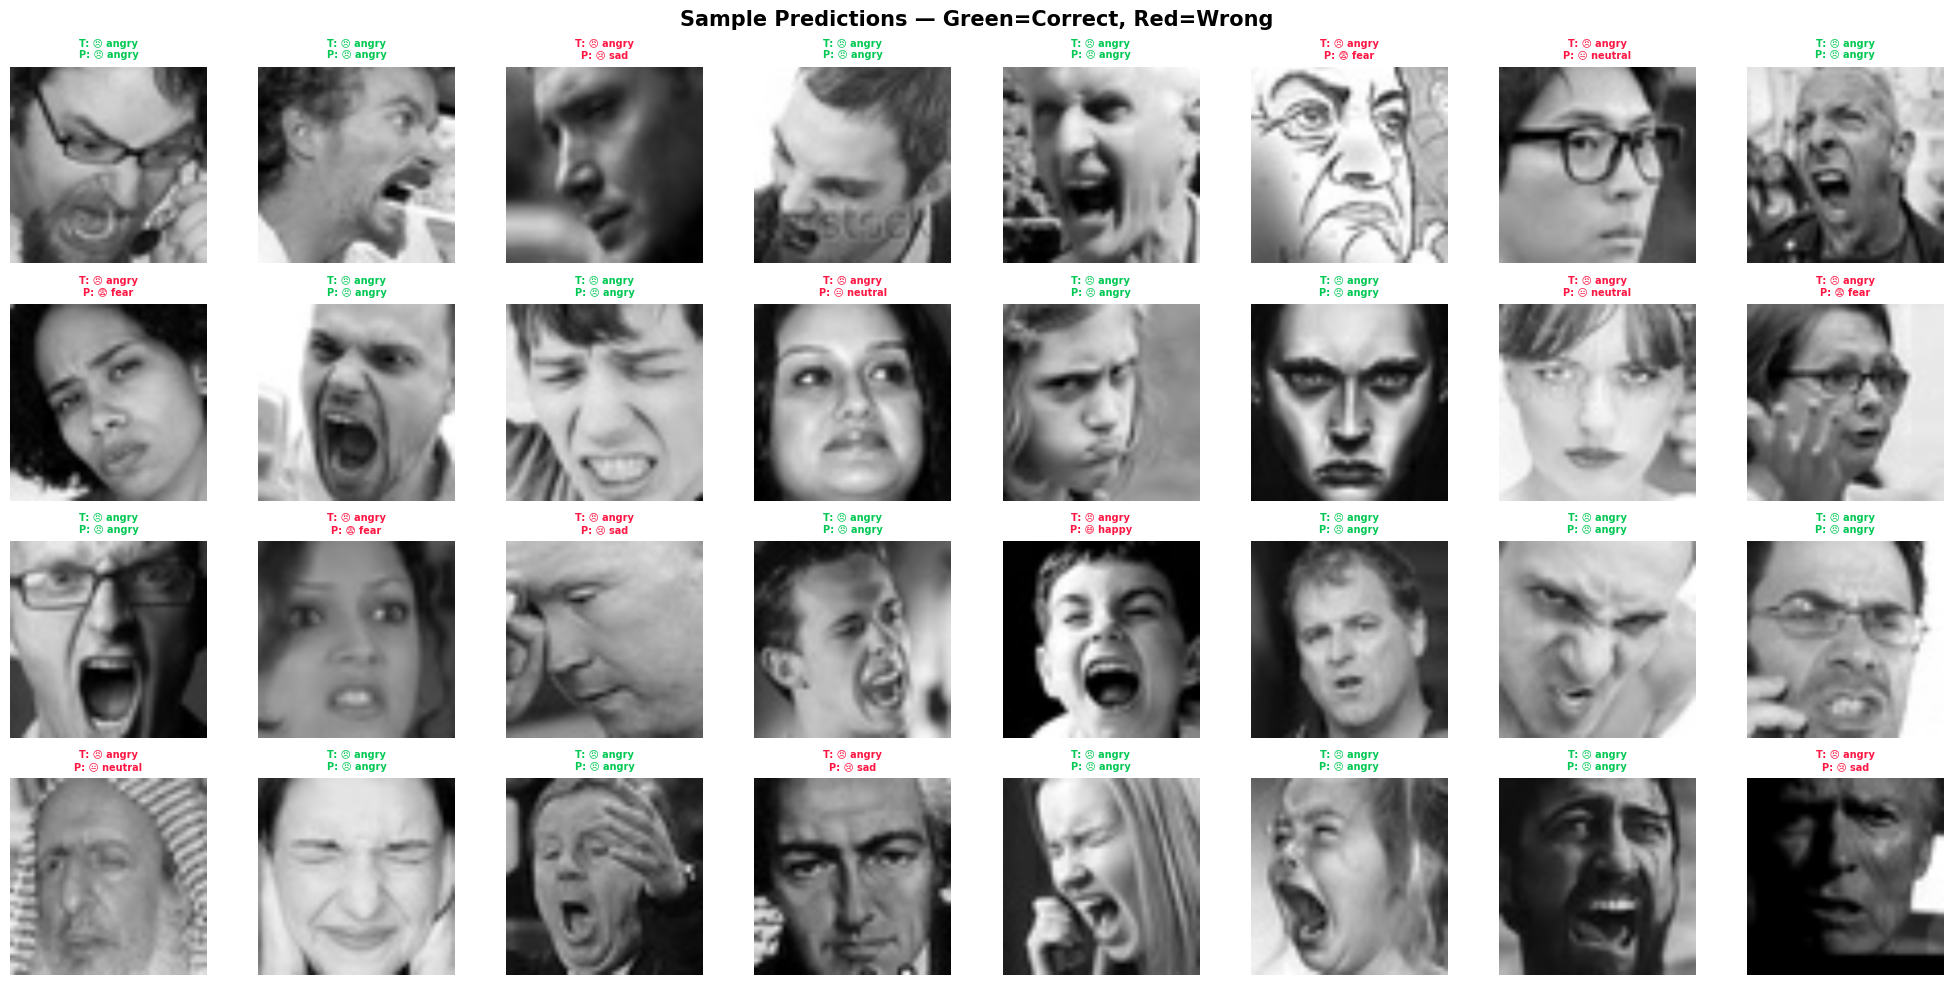

✅ Saved: plot_7_sample_predictions.png


In [34]:
# ── 8. Sample Predictions Grid ────────────────────────────────────
# Shows actual face images with true vs predicted labels

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle('Sample Predictions — Green=Correct, Red=Wrong',
             fontsize=15, fontweight='bold')

emotion_emoji = {
    'angry':'😠','disgust':'🤢','fear':'😨',
    'happy':'😄','neutral':'😐','sad':'😢','surprise':'😲'
}

sample_images, sample_true, sample_pred = [], [], []
for images, labels in test_ds_raw.take(5):
    imgs_f = tf.cast(images, tf.float32) / 255.0
    preds  = best_model(imgs_f, training=False).numpy()
    sample_images.extend(imgs_f.numpy())
    sample_true.extend(labels.numpy())
    sample_pred.extend(np.argmax(preds, axis=1))

for i, ax in enumerate(axes.flatten()):
    if i >= len(sample_images):
        ax.axis('off')
        continue
    ax.imshow(np.clip(sample_images[i], 0, 1))
    true_cls = CLASS_NAMES[sample_true[i]]
    pred_cls = CLASS_NAMES[sample_pred[i]]
    correct  = (sample_true[i] == sample_pred[i])
    color    = '#00C853' if correct else '#FF1744'
    ax.set_title(f"T: {emotion_emoji.get(true_cls,'')} {true_cls}\n"
                 f"P: {emotion_emoji.get(pred_cls,'')} {pred_cls}",
                 fontsize=7, color=color, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('plot_7_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_7_sample_predictions.png")

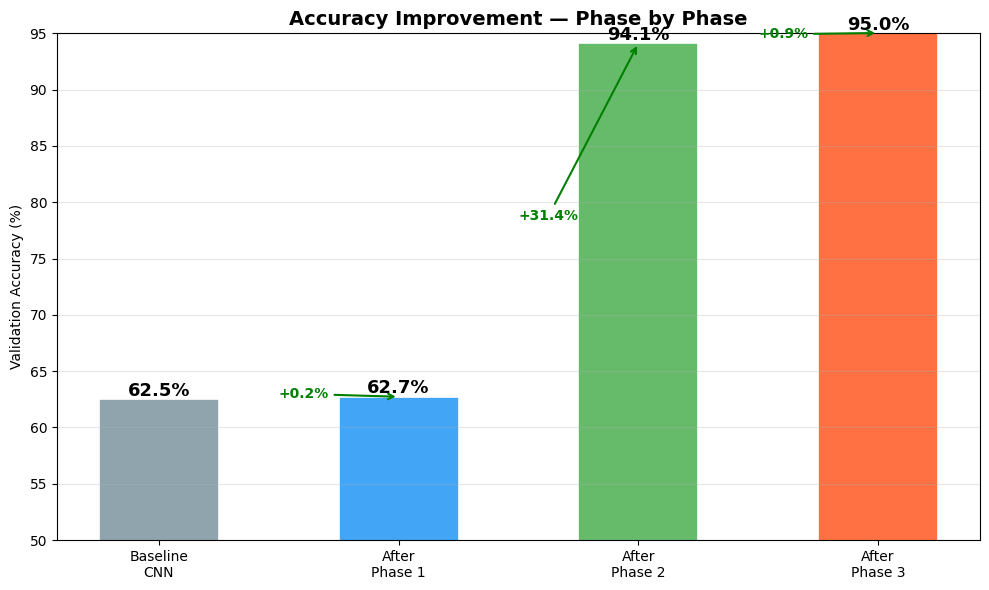

✅ Saved: plot_8_phase_improvement.png


In [35]:
# ── 9. Phase-wise Accuracy Improvement ───────────────────────────
# Shows how each training phase contributed to accuracy

phases     = ['Baseline\nCNN', 'After\nPhase 1', 'After\nPhase 2', 'After\nPhase 3']
accuracies = [
    62.52,
    max(history1.history['val_accuracy']) * 100,
    max(history2.history['val_accuracy']) * 100,
    max(history3.history['val_accuracy']) * 100,
]
colors_bar = ['#90A4AE', '#42A5F5', '#66BB6A', '#FF7043']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(phases, accuracies, color=colors_bar,
              edgecolor='white', linewidth=1.2, width=0.5)

# Value labels on bars
for bar, v in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')

# Improvement arrows
for i in range(len(accuracies) - 1):
    diff = accuracies[i+1] - accuracies[i]
    ax.annotate(f'+{diff:.1f}%',
                xy=(i+1, accuracies[i+1]),
                xytext=(i+0.5, (accuracies[i] + accuracies[i+1])/2),
                fontsize=10, color='green', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

ax.set_title('Accuracy Improvement — Phase by Phase',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_ylim(50, 95)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_8_phase_improvement.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_8_phase_improvement.png")

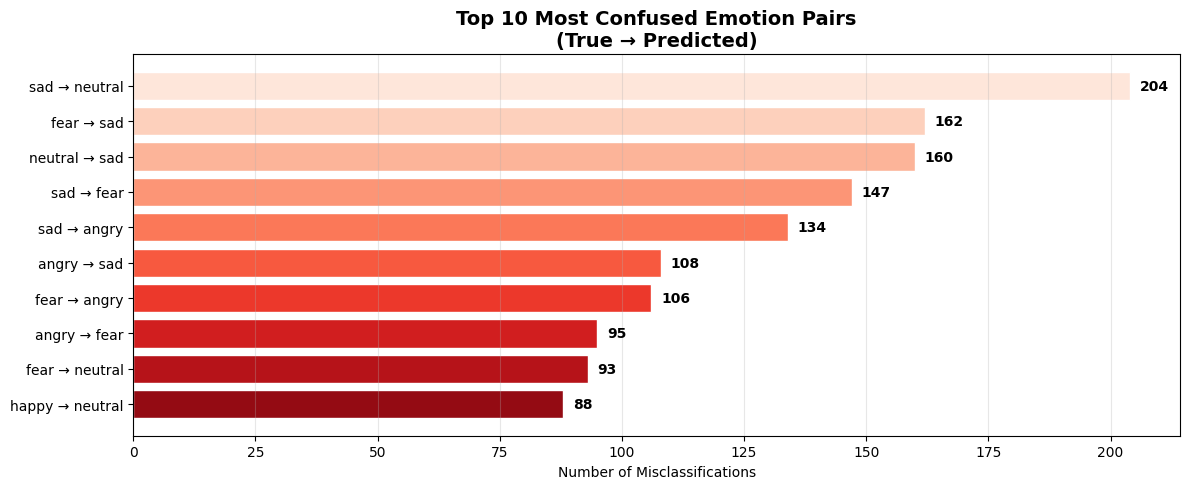

✅ Saved: plot_9_confused_pairs.png


In [36]:
# ── 10. Most Confused Emotion Pairs ──────────────────────────────
# Shows which emotions the model confuses most

cm_no_diag = cm.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)

confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_no_diag[i,j] > 0:
            confused_pairs.append({
                'pair': f"{CLASS_NAMES[i]} → {CLASS_NAMES[j]}",
                'count': int(cm_no_diag[i,j])
            })

confused_pairs = sorted(confused_pairs, key=lambda x: x['count'], reverse=True)[:10]
pair_labels = [p['pair'] for p in confused_pairs]
pair_counts = [p['count'] for p in confused_pairs]

fig, ax = plt.subplots(figsize=(12, 5))
colors_conf = sns.color_palette("Reds_r", len(pair_labels))
bars = ax.barh(pair_labels[::-1], pair_counts[::-1],
               color=colors_conf, edgecolor='white')

for bar, v in zip(bars, pair_counts[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(v), va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Most Confused Emotion Pairs\n(True → Predicted)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Misclassifications')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_9_confused_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_9_confused_pairs.png")

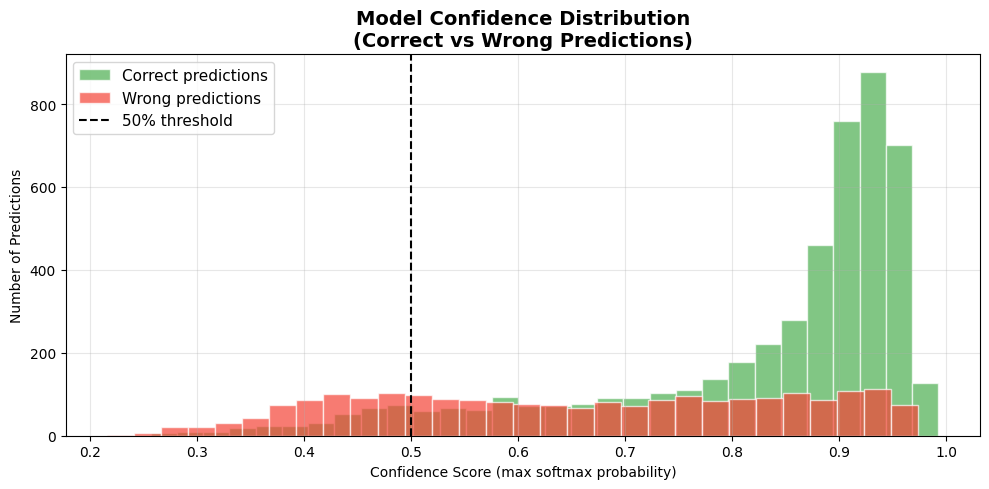

✅ Saved: plot_10_confidence_distribution.png


In [37]:
# ── 11. Confidence Distribution ──────────────────────────────────
# Shows how confident the model is on correct vs wrong predictions

all_probs, all_correct = [], []

for images, labels in test_ds_raw:
    imgs_f = tf.cast(images, tf.float32) / 255.0
    preds  = best_model(imgs_f, training=False).numpy()
    top_probs = np.max(preds, axis=1)
    top_preds = np.argmax(preds, axis=1)
    correct   = (top_preds == labels.numpy())
    all_probs.extend(top_probs)
    all_correct.extend(correct)

all_probs   = np.array(all_probs)
all_correct = np.array(all_correct)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(all_probs[all_correct],  bins=30, alpha=0.7,
        color='#4CAF50', label='Correct predictions', edgecolor='white')
ax.hist(all_probs[~all_correct], bins=30, alpha=0.7,
        color='#F44336', label='Wrong predictions',   edgecolor='white')

ax.axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='50% threshold')
ax.set_title('Model Confidence Distribution\n(Correct vs Wrong Predictions)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Confidence Score (max softmax probability)')
ax.set_ylabel('Number of Predictions')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_10_confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_10_confidence_distribution.png")

In [ ]:
# ── 12. Print final list of all saved plots ───────────────────────
print("\n📊 All research plots ready:")
all_plots = sorted([f for f in os.listdir('/kaggle/working/') if f.startswith('plot_')])
for p in all_plots:
    print(f"  ✅ {p}")
print(f"\nTotal: {len(all_plots)} plots — download from Kaggle Output panel")

In [38]:
import tensorflow as tf

# Load model
model = tf.keras.models.load_model('best_emotion_model.keras')

# Print summary
model.summary()

Model: "FER_EfficientNetB2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_10 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 7, 7, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 640)            │       901,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 640)            │         2,560 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 320)            │       205,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 320)            │         1,280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         2,247 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,065,472 (91.80 MB)

 Trainable params: 7,589,151 (28.95 MB)

 Non-trainable params: 1,298,017 (4.95 MB)

 Optimizer params: 15,178,304 (57.90 MB)